# Student Health Risk: EDA and Feature Engineering

## Objective

The previous notebooks established several baseline models:

- Logistic Regression
- CatBoost
- LightGBM
- XGBoost

CatBoost and LightGBM performed best, while XGBoost and Logistic Regression were weaker.

The goal of this notebook is to understand the dataset more deeply through focused exploratory data analysis and then create meaningful features that may improve model performance.

We will:

1. Load and inspect the data
2. Analyze the target distribution
3. Examine missing values
4. Study numerical features
5. Study categorical features
6. investigate relationships between features and the target
7. Create targeted engineered features
8. Evaluate whether those features improve CatBoost performance

## 1. Import Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from IPython.display import display


## 2. Load the Dataset

We load the training data, test data, and sample submission file from the Kaggle competition dataset.

In [3]:
DATA_PATH = "/kaggle/input/competitions/playground-series-s6e7"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")
sample_submission = pd.read_csv(
    f"{DATA_PATH}/sample_submission.csv"
)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", sample_submission.shape)

Train shape: (690088, 15)
Test shape: (295753, 14)
Submission shape: (295753, 2)


### Initial observation

The training set contains the target column `health_condition`, while the test set contains the same predictor columns without the target.

The `id` column is an identifier and will not normally be used as a predictive feature unless later analysis suggests that it contains useful structure.

## 3. Basic Dataset Inspection

Before deeper analysis, we inspect the column names, data types, example rows, and summary information.

This helps us identify:

- numerical and categorical features
- missing values
- possible data-quality issues
- columns that may require special handling

In [4]:
print("Training columns:")
print(train.columns.tolist())

Training columns:
['id', 'health_condition', 'sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake', 'diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


In [5]:
print("First 5 training rows:")
display(train.head(-5))

First 5 training rows:


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
690078,690078,fit,9.95,81.2,19.21,1526.0,NaN,36.2,3.00,balanced,low,average,active,occasional,female
690079,690079,at-risk,7.89,90.9,21.04,2608.0,12226.0,53.5,2.38,balanced,medium,good,moderate,yes,other
690080,690080,at-risk,6.20,58.2,25.78,1490.0,1441.0,12.8,1.81,veg,low,average,sedentary,occasional,male
690081,690081,at-risk,7.02,79.2,23.35,2314.0,8881.0,45.3,1.77,balanced,medium,good,moderate,no,other


In [6]:
print("Training data information:")
train.info()

Training data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  object 
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  object 
 10  stress_level             607277 non-null  object 
 11  sleep_quality            631757 non-null  object 
 12  physical_activity_level  653467 non-null  object 
 13  smoking_alcohol          661506 

### conclusion from column and data type inspection
we have 7 float numberical columns and 6 categorical columns. So in total we have 13 useful columns that we can use to map from features to target(ground truth). Ground truth is a column(health_condition). It has 3 categories: "Un-healthy, at risk, fit". So our problem is multiclassifier.


In [7]:
#seperate feature types for later analysis
target_column = "health_condition"
id_column = "id"

numerical_columns = train.select_dtypes(include=['int64', "float64"]).columns.tolist()
categorical_columns = train.select_dtypes(include=['object', "category"]).columns.tolist()

# Remove ID from numerical features
numerical_features = [

    col for col in numerical_columns

    if col != id_column

]


# Remove target from categorical features

categorical_features = [

    col for col in categorical_columns

    if col != target_column

]

print("Numerical features:")

print(numerical_features)

print("\nCategorical features:")

print(categorical_features)


Numerical features:
['sleep_duration', 'heart_rate', 'bmi', 'calorie_expenditure', 'step_count', 'exercise_duration', 'water_intake']

Categorical features:
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


## 4. Target Distribution

We examine how many training examples belong to each health-condition class.

This helps us understand:

- whether the target classes are imbalanced
- why balanced accuracy is an appropriate evaluation metric
- whether some classes may be harder for the model to learn

In [8]:
target_counts = train[target_column].value_counts()
target_percentages = train[target_column].value_counts(normalize=True)*100

target_summary = pd.DataFrame({

    "count": target_counts,

    "percentage": target_percentages.round(2)

})

display(target_summary)

,count,percentage
health_condition,,
at-risk,592561,85.87
unhealthy,57724,8.36
fit,39803,5.77


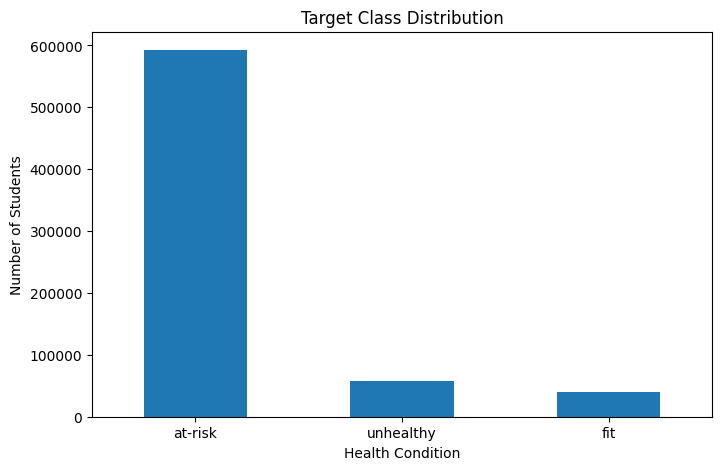

In [9]:
target_counts.plot(
    kind="bar",
    figsize=(8, 5),
    title="Target Class Distribution"
)

plt.xlabel("Health Condition")
plt.ylabel("Number of Students")
plt.xticks(rotation=0)
plt.show()

Just as a side note. Our target is highly imbalanced:
* at-risk: 85.87%
* unhealthy: 8.36%
* fit: 5.77%

## 5. Missing Values Analysis

We examine how many values are missing in each feature.

Missing values may be important because:

- some models handle them automatically
- some features may require imputation
- the fact that a value is missing may itself contain useful information

In [10]:
missing_count = train.isnull().sum()
missing_percentage = train.isnull().mean()*100

missing_summary = pd.DataFrame(
    {
        "missing_count":missing_count,
        "missing_percentage": missing_percentage.round(2)
    }
)

missing_summary = missing_summary[

    missing_summary["missing_count"] > 0

].sort_values(

    by="missing_percentage",

    ascending=False

)

display(missing_summary)

,missing_count,missing_percentage
stress_level,82811,12.00
sleep_duration,75999,11.01
sleep_quality,58331,8.45
calorie_expenditure,52853,7.66
water_intake,43477,6.30
physical_activity_level,36621,5.31
smoking_alcohol,28582,4.14
gender,21373,3.10
step_count,13916,2.02
bmi,13898,2.01


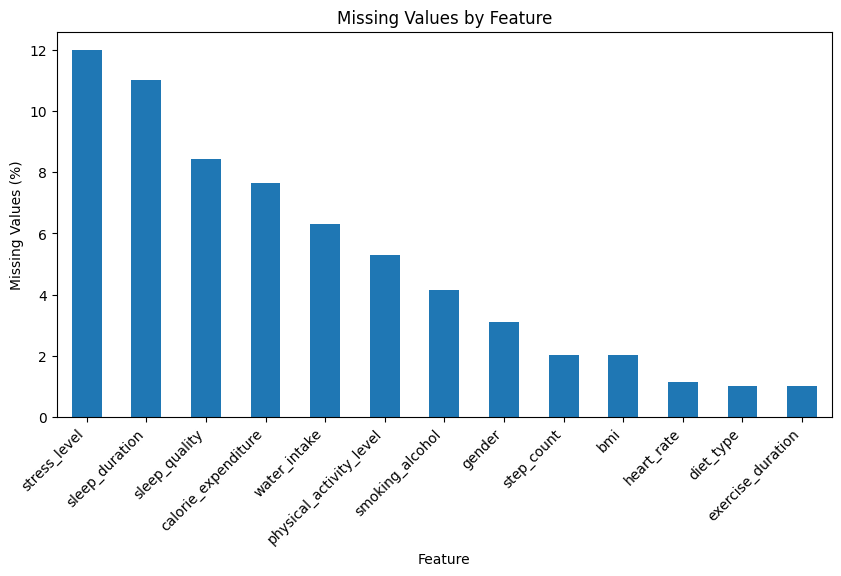

In [11]:
missing_summary['missing_percentage'].plot(
    kind="bar",
    figsize=(10, 5),
    title="Missing Values by Feature"
)
plt.xlabel("Feature")

plt.ylabel("Missing Values (%)")

plt.xticks(rotation=45, ha="right")

plt.show()

## Conclusion

Every predictor column contains some missing data.

* Missingness ranges from about 1% to 12%.
* stress_level has the highest missing rate at 12%.
* sleep_duration follows at 11.01%.
* No feature has an extremely high missing rate, so dropping columns is unnecessary.

For CatBoost, we can keep numerical missing values as NaN and represent missing categorical values consistently. Later, we should test whether adding missing-value indicator features improves validation performance.

## 6. Numerical Feature Analysis

We now inspect the distribution of every numerical feature.

Goals:
- Understand the range of each feature.
- Detect skewed distributions.
- Identify possible outliers.
- Decide whether transformations or clipping may be useful later.

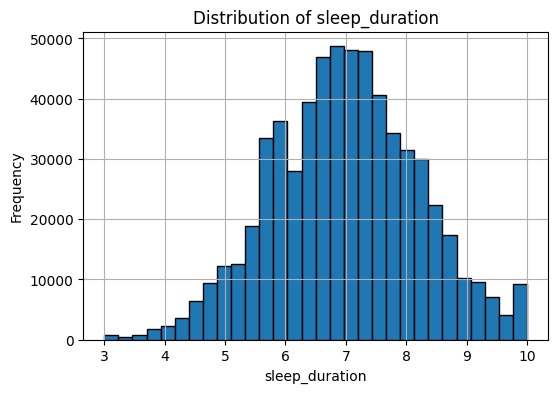

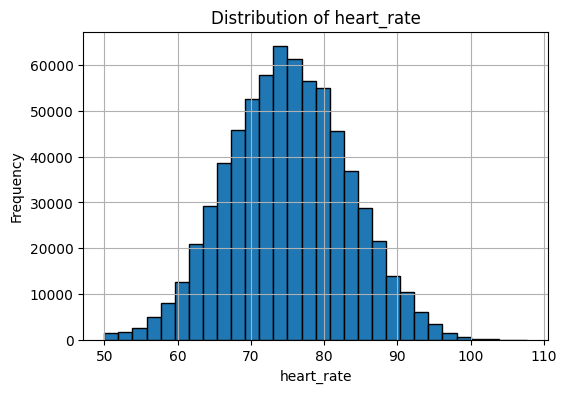

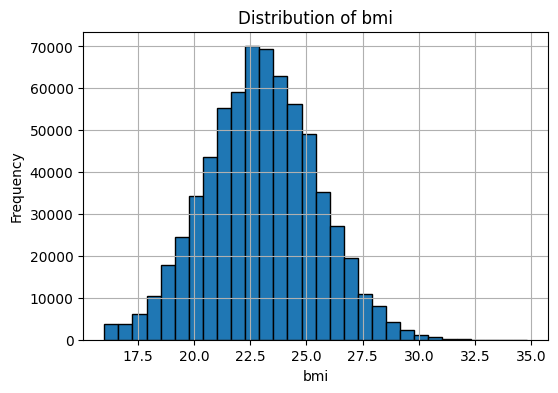

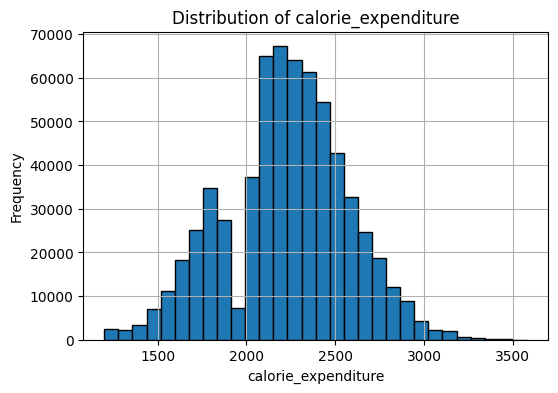

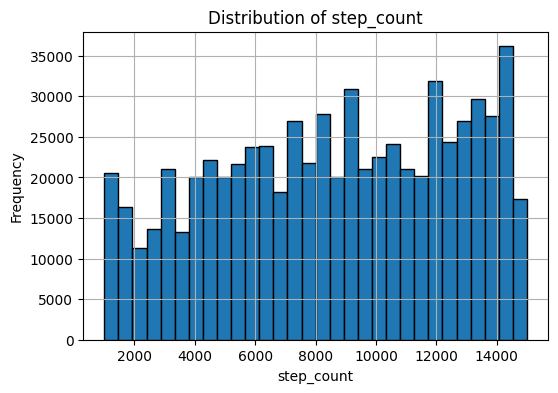

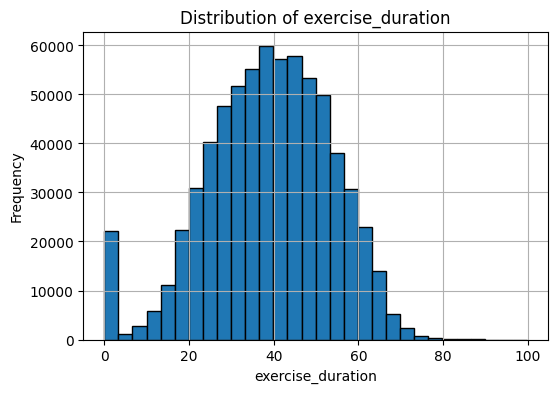

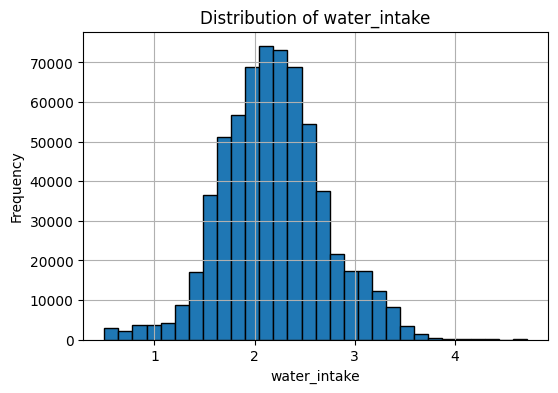

In [12]:
for feature in numerical_features:
    plt.figure(figsize=(6,4))

    train[feature].hist(
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.show()

## 7. Numerical Summary Statistics

We compute descriptive statistics for each numerical feature.

This helps us identify:
- unusual minimum/maximum values,
- possible outliers,
- different feature scales,
- skewed variables.

### we are looking forward to get more info on...


From the histograms and summary statistics we will identify:

- Features with strong skewness.
- Features that may contain outliers.
- Features that may benefit from log transformation.
- Features that may require clipping.
- Any suspicious values that deserve further investigation.

These observations will directly guide future feature engineering.

In [13]:
display(train[numerical_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


### Conclusion

The numerical summary statistics confirm the observations from the histograms.

Key findings:

- sleep_duration, heart_rate, and bmi are approximately normally distributed.
- exercise_duration contains legitimate zero values, indicating many students reported no exercise.
- calorie_expenditure appears to contain multiple subgroups despite having a mean close to its median.
- step_count spans a wide range but does not exhibit obvious extreme outliers.
- water_intake is only slightly right-skewed.

Overall, there are no unrealistic values or severe outliers that require immediate removal. Most numerical variables appear well-behaved, allowing us to focus next on relationships between features and the target variable to identify useful patterns for feature engineering.

## 8. Numerical Features vs. Target

We compare the distribution of each numerical feature across the three health-condition classes.

This helps us identify:

- which features separate the classes,
- where class distributions overlap,
- possible thresholds or interactions,
- useful ideas for feature engineering.

<Figure size 800x500 with 0 Axes>

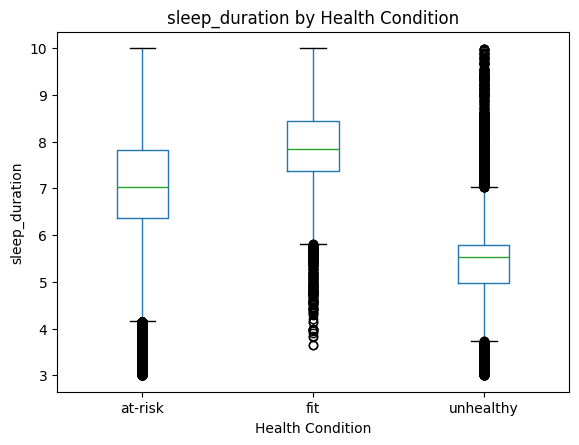

<Figure size 800x500 with 0 Axes>

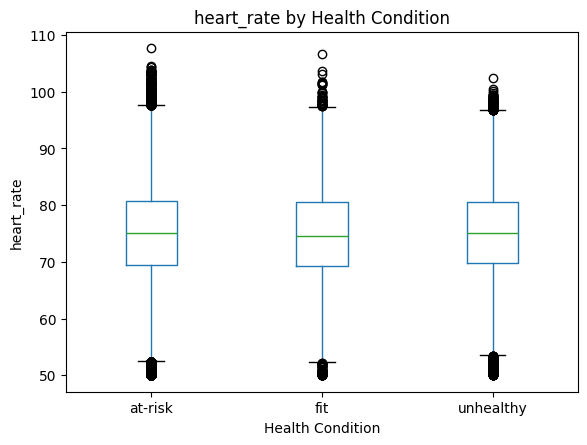

<Figure size 800x500 with 0 Axes>

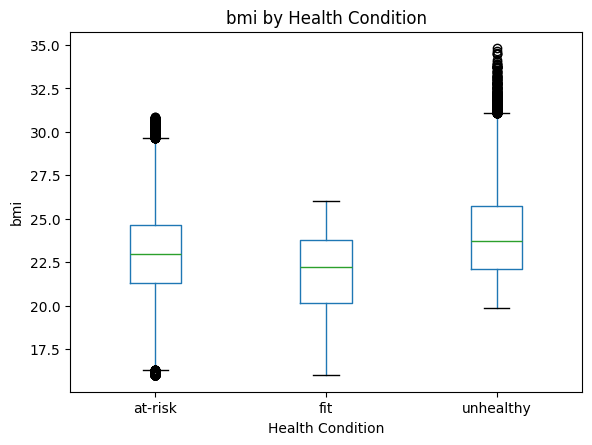

<Figure size 800x500 with 0 Axes>

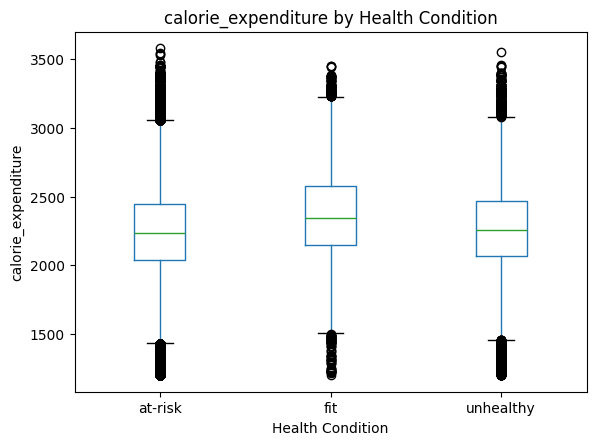

<Figure size 800x500 with 0 Axes>

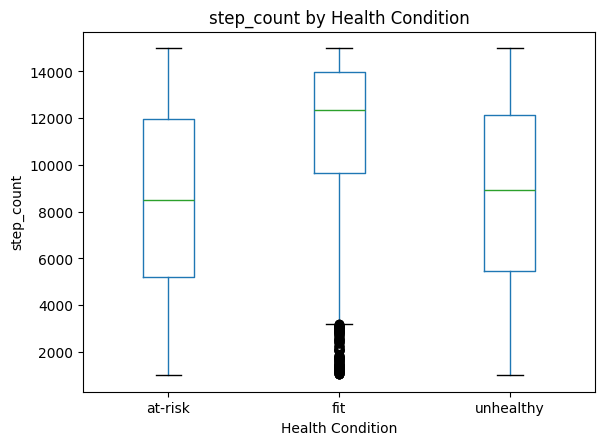

<Figure size 800x500 with 0 Axes>

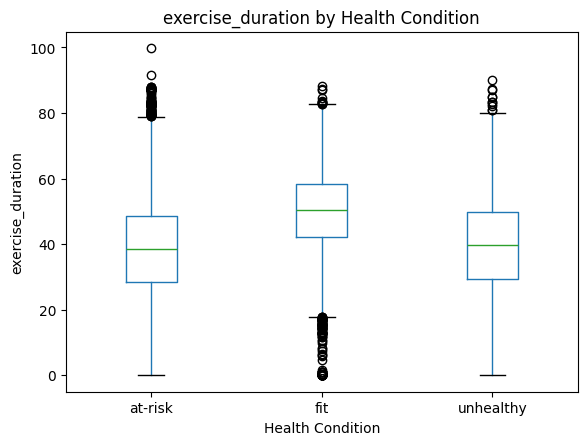

<Figure size 800x500 with 0 Axes>

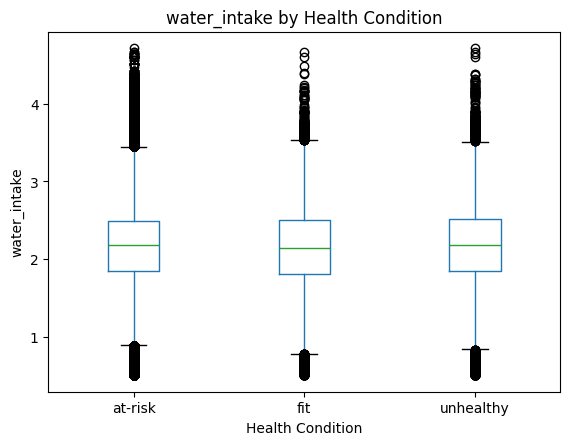

In [14]:
for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    train.boxplot(
        column=feature,
        by=target_column,
        grid=False
    )

    plt.title(f"{feature} by Health Condition")
    plt.suptitle("")
    plt.xlabel("Health Condition")
    plt.ylabel(feature)

    plt.show()

### Conclusion

The numerical feature analysis reveals several useful class-separation patterns:

- `sleep_duration` is one of the strongest numerical predictors. Fit students generally sleep longer, while unhealthy students sleep substantially less.
- `step_count` and `exercise_duration` are notably higher among fit students.
- `bmi` tends to be lower for fit students and higher for unhealthy students.
- `calorie_expenditure` shows some separation, although the class distributions still overlap.
- `heart_rate` and `water_intake` show very similar distributions across all target classes, so they may be weak predictors when used alone.

These patterns suggest several promising feature-engineering ideas:

- combine sleep duration with sleep quality,
- combine step count with exercise duration,
- create overall activity indicators,
- create BMI and activity interactions,
- investigate whether low sleep and low activity together strongly indicate unhealthy status.

## 9. Categorical Features vs. Target

We compare the target proportions within each categorical feature.

This helps us identify categories that are strongly associated with fit, at-risk, or unhealthy outcomes.

health_condition,at-risk,fit,unhealthy
diet_type,,,
balanced,85.14,6.12,8.74
non-veg,86.78,5.16,8.06
veg,85.67,6.04,8.30


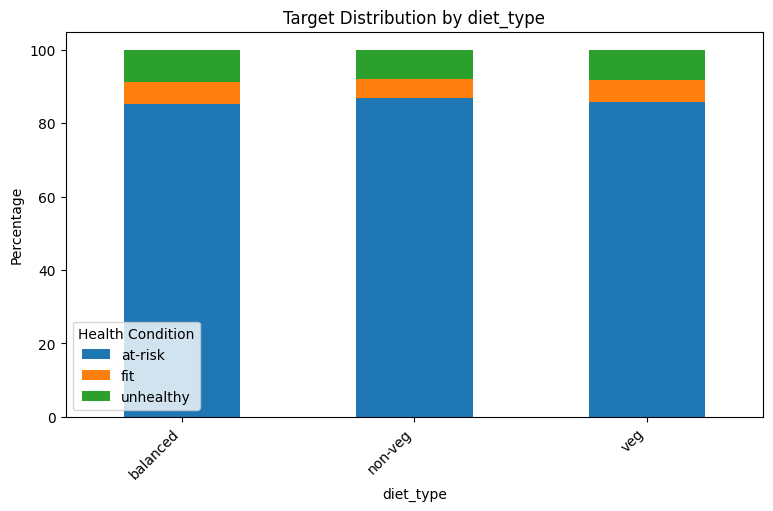

health_condition,at-risk,fit,unhealthy
stress_level,,,
high,71.78,0.35,27.87
low,79.67,20.06,0.28
medium,99.39,0.30,0.31


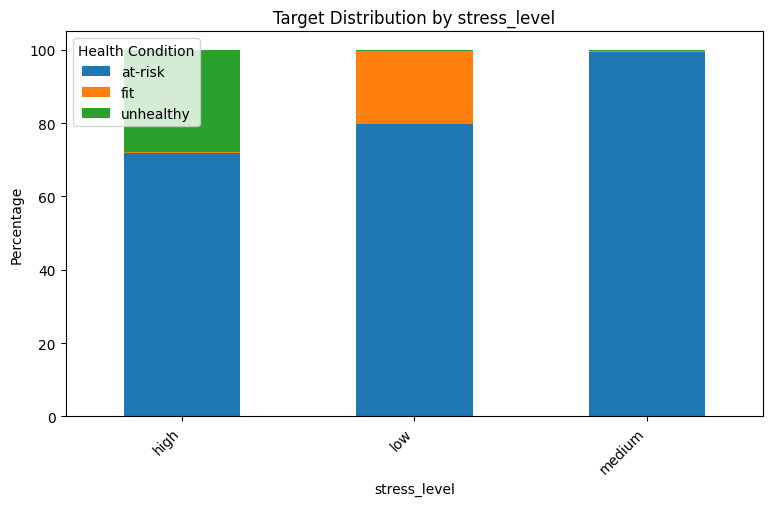

health_condition,at-risk,fit,unhealthy
sleep_quality,,,
average,85.93,5.73,8.34
good,88.78,8.17,3.05
poor,82.96,3.46,13.58


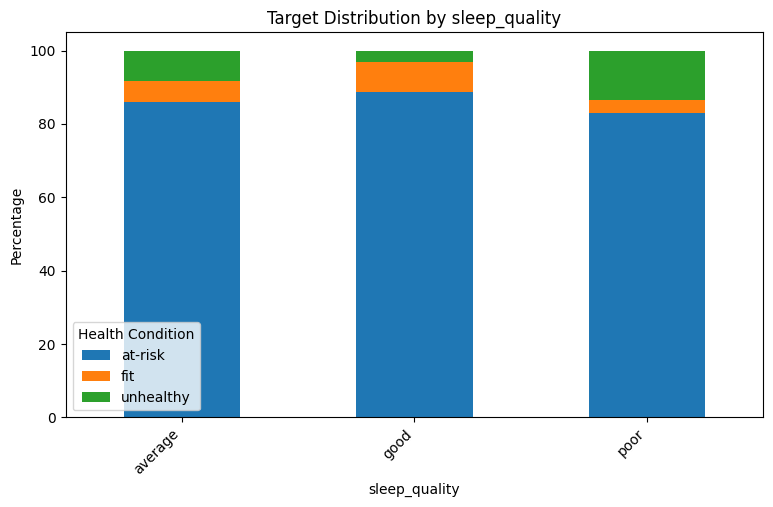

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
active,74.31,17.16,8.53
moderate,91.15,0.31,8.54
sedentary,91.73,0.24,8.03


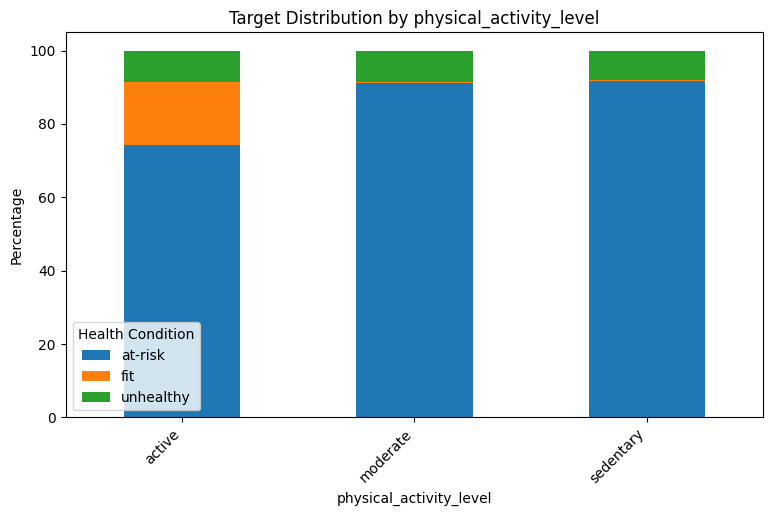

health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
no,86.68,7.86,5.46
occasional,85.85,5.78,8.36
yes,85.10,3.70,11.20


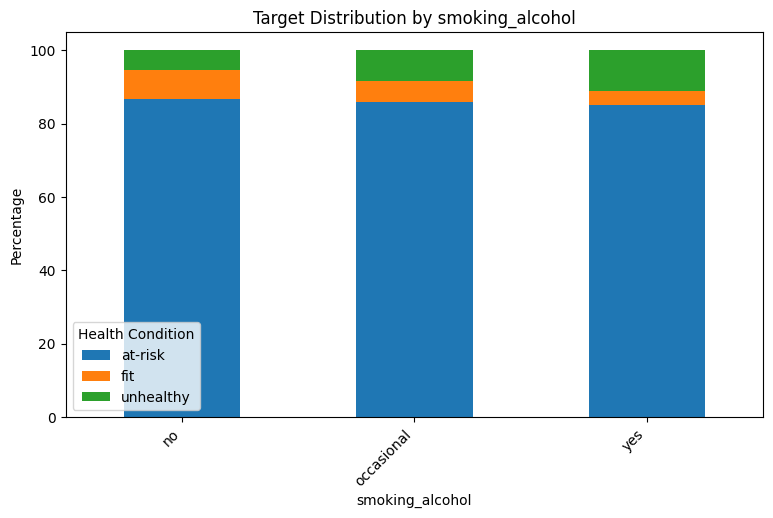

health_condition,at-risk,fit,unhealthy
gender,,,
female,85.74,5.71,8.55
male,85.70,6.26,8.05
other,86.21,5.29,8.50


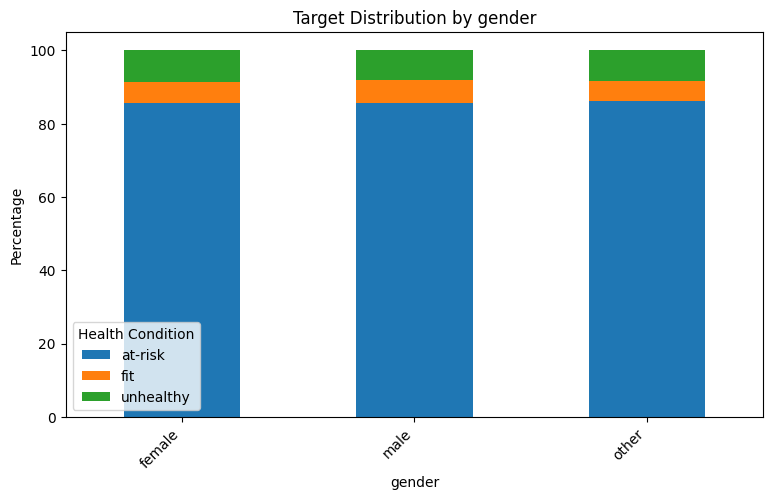

In [15]:
for feature in categorical_features:
    category_target_distribution = pd.crosstab(
        train[feature],
        train[target_column],
        normalize="index"
    ) * 100

    display(category_target_distribution.round(2))

    category_target_distribution.plot(
        kind="bar",
        stacked=True,
        figsize=(9, 5),
        title=f"Target Distribution by {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Percentage")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Health Condition")
    plt.show()

### Conclusion

The categorical feature analysis reveals several highly informative predictors.

**Strong predictors**

- stress_level
- physical_activity_level
- sleep_quality

These variables show clear differences in the target distribution and are likely to contribute substantially to model performance.

Smoking/alcohol exhibits a weaker but consistent trend, while diet type and gender show only minor differences across classes.

Potential feature-engineering ideas include:

- sleep_duration × sleep_quality
- stress_level × sleep_duration
- physical_activity_level × exercise_duration
- physical_activity_level × step_count
- BMI × physical_activity_level
- missing-value indicator features

## 10. Numerical Feature Correlations

We examine how strongly the numerical features move together.

This helps us identify:

- redundant features,
- strongly related variables,
- possible interaction features,
- relationships that may help explain model behavior.

In [16]:
correlation_matrix = train[numerical_features].corr()

display(correlation_matrix.round(2))

,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake
sleep_duration,1.00,-0.01,-0.07,-0.00,0.00,0.00,0.0
heart_rate,-0.01,1.00,0.00,-0.00,-0.01,-0.01,0.0
bmi,-0.07,0.00,1.00,0.12,-0.02,-0.02,0.0
calorie_expenditure,-0.00,-0.00,0.12,1.00,0.40,0.39,0.0
step_count,0.00,-0.01,-0.02,0.40,1.00,0.44,-0.0
exercise_duration,0.00,-0.01,-0.02,0.39,0.44,1.00,0.0
water_intake,0.00,0.00,0.00,0.00,-0.00,0.00,1.0


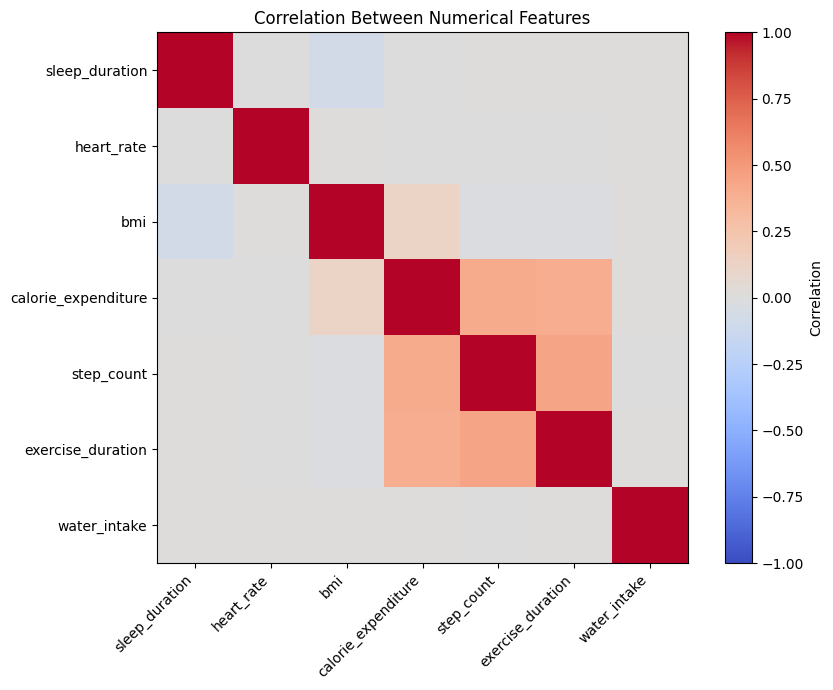

In [17]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(numerical_features)),
    numerical_features,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numerical_features)),
    numerical_features
)

plt.title("Correlation Between Numerical Features")
plt.tight_layout()
plt.show()

### Conclusion

The numerical features exhibit relatively low pairwise correlations.

The strongest relationships are:

- step_count ↔ exercise_duration (0.44)
- calorie_expenditure ↔ step_count (0.40)
- calorie_expenditure ↔ exercise_duration (0.39)

These moderate positive correlations are expected because they all measure aspects of physical activity.

Most other feature pairs have correlations close to zero, suggesting that each numerical feature contributes unique information rather than duplicating another feature.

No evidence of severe multicollinearity is observed, so all numerical features should be retained.

Possible feature engineering ideas include creating activity-based interaction features such as calories per step, calories per minute, and overall activity scores.

## 11. Missing Values vs. Target

We examine whether the absence of a feature value is related to the target class.

If missingness differs across `fit`, `at-risk`, and `unhealthy`, then a missing-value indicator may be useful as an engineered feature.

In [18]:
missing_target_results = []

for feature in numerical_features + categorical_features:

    # Create temporary missing/not-missing labels
    missing_status = train[feature].isnull().map({
        True: "Missing",
        False: "Not Missing"
    })

    # Calculate target percentages within each missingness group
    distribution = pd.crosstab(
        missing_status,
        train[target_column],
        normalize="index"
    ) * 100

    print(f"\nMissingness analysis for: {feature}")
    display(distribution.round(2))


Missingness analysis for: sleep_duration


health_condition,at-risk,fit,unhealthy
sleep_duration,,,
Missing,85.93,5.73,8.34
Not Missing,85.86,5.77,8.37



Missingness analysis for: heart_rate


health_condition,at-risk,fit,unhealthy
heart_rate,,,
Missing,87.08,5.53,7.39
Not Missing,85.85,5.77,8.38



Missingness analysis for: bmi


...

health_condition,at-risk,fit,unhealthy
physical_activity_level,,,
Missing,85.94,5.72,8.34
Not Missing,85.86,5.77,8.37



Missingness analysis for: smoking_alcohol


health_condition,at-risk,fit,unhealthy
smoking_alcohol,,,
Missing,85.68,5.77,8.55
Not Missing,85.88,5.77,8.36



Missingness analysis for: gender


health_condition,at-risk,fit,unhealthy
gender,,,
Missing,85.83,5.57,8.60
Not Missing,85.87,5.77,8.36


### Conclusion

For most features, missing and non-missing rows have almost identical target distributions.

This suggests that missingness is mostly random and that creating missing-value indicators for every feature is unlikely to add much predictive value.

The strongest exception is `bmi`:

- Rows with missing BMI contain a higher percentage of fit students.
- Rows with observed BMI contain a higher percentage of unhealthy students.

Therefore, `bmi_missing` may be a useful engineered feature. A `heart_rate_missing` indicator could also be tested, but its signal appears weaker.

We should avoid automatically adding missing indicators for all columns and instead test only the most promising ones.

## 12. First Feature Engineering Batch

We now create a small set of meaningful interaction features based on the strongest patterns found during EDA.

The goal is to test whether combining related variables helps CatBoost distinguish the health-condition classes more effectively.

We will begin with:

- sleep duration × sleep quality
- step count ÷ exercise duration
- calorie expenditure ÷ exercise duration
- BMI × activity level
- BMI missing indicator

In [19]:
# Create copies so the original data remains unchanged
train_fe = train.copy()
test_fe = test.copy()

In [20]:
# BMI missing-value indicator
train_fe["bmi_missing"] = train_fe["bmi"].isnull().astype(int)
test_fe["bmi_missing"] = test_fe["bmi"].isnull().astype(int)

### Feature 1: BMI Missing Indicator

Missing BMI showed a noticeably different target distribution, so we create a binary feature:

- `1` if BMI is missing
- `0` if BMI is present

### Feature 2: Sleep Duration × Sleep Quality

Sleep duration was one of the strongest numerical predictors, and sleep quality also showed clear class differences.

We combine them into a single sleep-health score.

In [21]:
# Convert sleep quality into ordered numerical values
sleep_quality_map = {
    "poor": 1,
    "average": 2,
    "good": 3
}

train_fe["sleep_quality_score"] = train_fe["sleep_quality"].map(sleep_quality_map)
test_fe["sleep_quality_score"] = test_fe["sleep_quality"].map(sleep_quality_map)

# Combine sleep duration and sleep quality
train_fe["sleep_health_score"] = (
    train_fe["sleep_duration"] *
    train_fe["sleep_quality_score"]
)

test_fe["sleep_health_score"] = (
    test_fe["sleep_duration"] *
    test_fe["sleep_quality_score"]
)

In [22]:
train_fe[
    [
        "sleep_duration",
        "sleep_quality",
        "sleep_quality_score",
        "sleep_health_score"
    ]
].head()

,sleep_duration,sleep_quality,sleep_quality_score,sleep_health_score
0,5.22,average,2.0,10.44
1,5.53,average,2.0,11.06
2,5.29,poor,1.0,5.29
3,4.70,average,2.0,9.40
4,7.23,average,2.0,14.46


In [23]:
sleep_score_summary = (
    train_fe
    .groupby(target_column)["sleep_health_score"]
    .describe()[["mean", "std", "25%", "50%", "75%"]]
    .round(2)
)

display(sleep_score_summary)

,mean,std,25%,50%,75%
health_condition,,,,,
at-risk,14.59,6.97,7.24,14.16,20.61
fit,18.12,6.69,14.46,17.90,23.76
unhealthy,8.50,4.13,5.39,5.90,11.28


<Figure size 800x500 with 0 Axes>

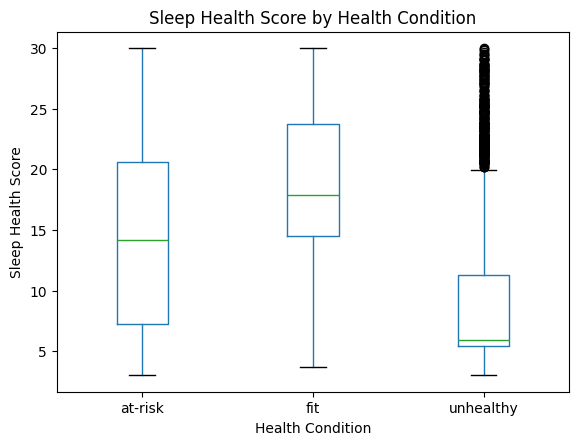

In [24]:
plt.figure(figsize=(8,5))

train_fe.boxplot(
    column="sleep_health_score",
    by=target_column,
    grid=False
)

plt.suptitle("")
plt.title("Sleep Health Score by Health Condition")
plt.xlabel("Health Condition")
plt.ylabel("Sleep Health Score")

plt.show()

The engineered sleep_health_score provides better class separation than either sleep duration or sleep quality alone. Fit students tend to have the highest scores, unhealthy students the lowest, and at-risk students fall between them. This suggests that combining related features can capture meaningful patterns and may improve model performance.

### Feature 3: Steps per Exercise Minute

`step_count` and `exercise_duration` were both useful predictors and moderately correlated.

This feature measures how many steps a student takes per minute of reported exercise.

In [25]:
# Avoid division by zero by replacing 0 exercise minutes with NaN
train_fe["steps_per_exercise_minute"] = (
    train_fe["step_count"] /
    train_fe["exercise_duration"].replace(0, np.nan)
)

test_fe["steps_per_exercise_minute"] = (
    test_fe["step_count"] /
    test_fe["exercise_duration"].replace(0, np.nan)
)

In [26]:
display(
    train_fe[
        [
            "step_count",
            "exercise_duration",
            "steps_per_exercise_minute"
        ]
    ].head()
)

,step_count,exercise_duration,steps_per_exercise_minute
0,1326.0,19.8,66.969697
1,9891.0,49.9,198.216433
2,14216.0,38.1,373.123360
3,7174.0,59.9,119.766277
4,6584.0,46.0,143.130435


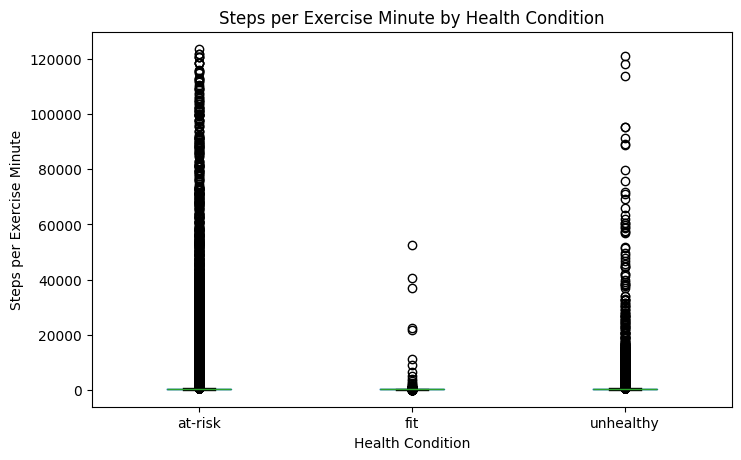

In [27]:
train_fe.boxplot(
    column="steps_per_exercise_minute",
    by=target_column,
    grid=False,
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Steps per Exercise Minute by Health Condition")
plt.xlabel("Health Condition")
plt.ylabel("Steps per Exercise Minute")
plt.show()

In [28]:
train_fe["steps_per_exercise_minute"].describe(percentiles=[0.95, 0.99])

count    653250.000000
mean        354.895837
std        2203.185984
min          20.405680
50%         221.301527
95%         461.586487
99%         943.458104
max      123760.000000
Name: steps_per_exercise_minute, dtype: float64

In [29]:
train_fe["log_steps_per_exercise_minute"] = np.log1p(
    train_fe["steps_per_exercise_minute"]
)

test_fe["log_steps_per_exercise_minute"] = np.log1p(
    test_fe["steps_per_exercise_minute"]
)

In [30]:
train_fe.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender,bmi_missing,sleep_quality_score,sleep_health_score,steps_per_exercise_minute,log_steps_per_exercise_minute
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female,0,2.0,10.44,66.969697,4.219062
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other,0,2.0,11.06,198.216433,5.294392
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male,0,1.0,5.29,373.123360,5.924586
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female,0,2.0,9.40,119.766277,4.793857
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male,0,2.0,14.46,143.130435,4.970719


### Feature 4: Activity Score

`exercise_duration` and `physical_activity_level` both showed strong relationships with the target.

We convert physical activity level into an ordered numerical score and combine it with exercise duration.

In [31]:
# Convert physical activity level into ordered numerical values
activity_level_map = {
    "sedentary": 1,
    "moderate": 2,
    "active": 3
}

train_fe["activity_level_score"] = (
    train_fe["physical_activity_level"]
    .map(activity_level_map)
)

test_fe["activity_level_score"] = (
    test_fe["physical_activity_level"]
    .map(activity_level_map)
)

# Combine exercise duration and activity level
train_fe["activity_score"] = (
    train_fe["exercise_duration"] *
    train_fe["activity_level_score"]
)

test_fe["activity_score"] = (
    test_fe["exercise_duration"] *
    test_fe["activity_level_score"]
)

In [32]:
display(
    train_fe[
        [
            "exercise_duration",
            "physical_activity_level",
            "activity_level_score",
            "activity_score"
        ]
    ].head()
)

,exercise_duration,physical_activity_level,activity_level_score,activity_score
0,19.8,sedentary,1.0,19.8
1,49.9,moderate,2.0,99.8
2,38.1,active,3.0,114.3
3,59.9,active,3.0,179.7
4,46.0,sedentary,1.0,46.0


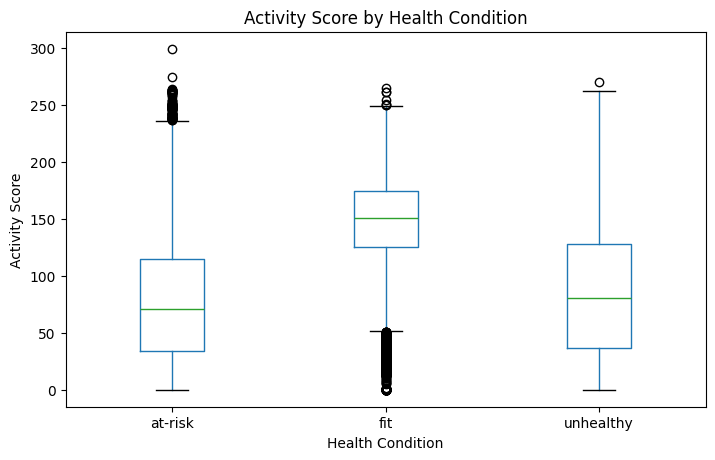

In [33]:
train_fe.boxplot(
    column="activity_score",
    by=target_column,
    grid=False,
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Activity Score by Health Condition")
plt.xlabel("Health Condition")
plt.ylabel("Activity Score")
plt.show()

### Activity Score Conclusion

The engineered `activity_score` shows strong separation between the target classes.

- Fit students have substantially higher activity scores.
- At-risk and unhealthy students generally have lower scores.
- Some overlap remains, but the class medians are clearly different.

This suggests that combining exercise duration with physical activity level captures useful information and is a promising feature for model evaluation.

### Feature 5: Stress–Sleep Risk Score

Stress level and sleep behavior were among the strongest predictors.

We convert stress level into an ordered numerical score and combine it with sleep duration.

Higher stress and shorter sleep should produce a larger risk score.

In [34]:
# Convert stress level into ordered numerical values
stress_level_map = {
    "low": 1,
    "medium": 2,
    "high": 3
}

train_fe["stress_level_score"] = (
    train_fe["stress_level"]
    .map(stress_level_map)
)

test_fe["stress_level_score"] = (
    test_fe["stress_level"]
    .map(stress_level_map)
)

# Higher stress and lower sleep produce a larger risk score
train_fe["stress_sleep_risk_score"] = (
    train_fe["stress_level_score"] /
    train_fe["sleep_duration"]
)

test_fe["stress_sleep_risk_score"] = (
    test_fe["stress_level_score"] /
    test_fe["sleep_duration"]
)

In [35]:
display(
    train_fe[
        [
            "stress_level",
            "stress_level_score",
            "sleep_duration",
            "stress_sleep_risk_score"
        ]
    ].head()
)

,stress_level,stress_level_score,sleep_duration,stress_sleep_risk_score
0,high,3.0,5.22,0.574713
1,low,1.0,5.53,0.180832
2,high,3.0,5.29,0.567108
3,high,3.0,4.70,0.638298
4,NaN,NaN,7.23,NaN


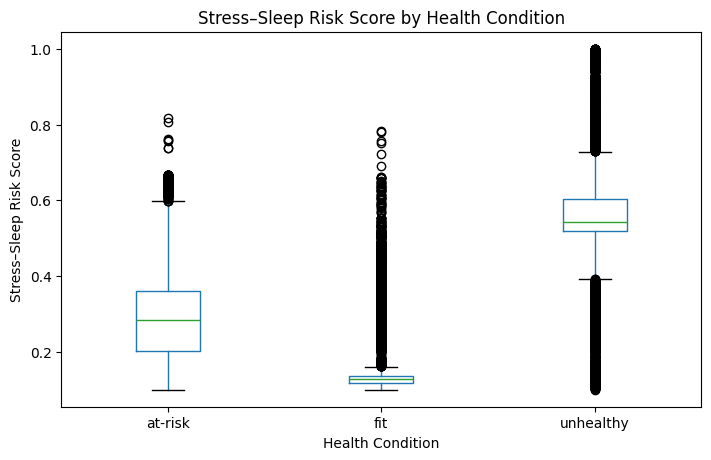

In [36]:
train_fe.boxplot(
    column="stress_sleep_risk_score",
    by=target_column,
    grid=False,
    figsize=(8, 5)
)

plt.suptitle("")
plt.title("Stress–Sleep Risk Score by Health Condition")
plt.xlabel("Health Condition")
plt.ylabel("Stress–Sleep Risk Score")
plt.show()

### Stress–Sleep Risk Score Conclusion

The engineered `stress_sleep_risk_score` shows excellent separation between the three target classes.

Observations:

- Fit students have the lowest risk scores.
- At-risk students lie in the middle.
- Unhealthy students have the highest scores.

This suggests that combining stress level and sleep duration captures meaningful interactions that are more informative than either feature alone. This feature will be retained for model evaluation.

In [37]:
train_fe.head()

,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,...,gender,bmi_missing,sleep_quality_score,sleep_health_score,steps_per_exercise_minute,log_steps_per_exercise_minute,activity_level_score,activity_score,stress_level_score,stress_sleep_risk_score
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,...,female,0,2.0,10.44,66.969697,4.219062,1.0,19.8,3.0,0.574713
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,...,other,0,2.0,11.06,198.216433,5.294392,2.0,99.8,1.0,0.180832
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,...,male,0,1.0,5.29,373.123360,5.924586,3.0,114.3,3.0,0.567108
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,...,female,0,2.0,9.40,119.766277,4.793857,3.0,179.7,3.0,0.638298
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,...,male,0,2.0,14.46,143.130435,4.970719,1.0,46.0,NaN,NaN


In [38]:
# Remove columns that should not be used as predictors
X_fe = train_fe.drop(columns=["id", target_column])
y = train_fe[target_column]

X_test_fe = test_fe.drop(columns=["id"])

print("Engineered training shape:", X_fe.shape)
print("Engineered test shape:", X_test_fe.shape)

Engineered training shape: (690088, 22)
Engineered test shape: (295753, 22)


In [39]:
categorical_features_fe = X_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical features:")
print(categorical_features_fe)

Categorical features:
['diet_type', 'stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol', 'gender']


### Prepare Categorical Features for CatBoost

CatBoost requires categorical values to be strings rather than `NaN`.

We replace missing categorical values with the label `"Missing"` in both the training and test sets.

In [40]:
# Replace missing categorical values with a consistent label
for column in categorical_features_fe:
    X_fe[column] = X_fe[column].fillna("Missing").astype(str)
    X_test_fe[column] = X_test_fe[column].fillna("Missing").astype(str)

print(X_fe[categorical_features_fe].isnull().sum())

diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64


### CatBoost Cross-Validation Setup

We use 5-fold stratified cross-validation so each fold preserves the target-class distribution.

We will store:

- balanced accuracy for each fold,
- out-of-fold predictions for the training data,
- averaged class probabilities for the test data.

In [41]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

# Create 5 stratified folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Store validation predictions for every training row
oof_predictions_fe = np.empty(len(X_fe), dtype=object)

# Store averaged probabilities for the test set
test_probabilities_fe = np.zeros(
    (len(X_test_fe), y.nunique())
)

# Store balanced accuracy for each fold
fold_scores_fe = []

### Train CatBoost with Engineered Features

We train one CatBoost model for each fold, evaluate it using balanced accuracy, and average the test probabilities across all five models.

In [ ]:
for fold, (train_index, valid_index) in enumerate(
    skf.split(X_fe, y),
    start=1
):
    print(f"\nFold {fold}")

    # Split data for the current fold
    X_train = X_fe.iloc[train_index]
    X_valid = X_fe.iloc[valid_index]

    y_train = y.iloc[train_index]
    y_valid = y.iloc[valid_index]

    # Create CatBoost model
    model = CatBoostClassifier(
        iterations=1000,
        depth=7,
        learning_rate=0.05,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        random_seed=42,
        verbose=100
    )

    # Train model
    model.fit(
        X_train,
        y_train,
        cat_features=categorical_features_fe,
        eval_set=(X_valid, y_valid),
        early_stopping_rounds=100,
        verbose=100
    )

    # Validation predictions
    valid_predictions = model.predict(X_valid).reshape(-1)

    # Calculate fold score
    fold_score = balanced_accuracy_score(
        y_valid,
        valid_predictions
    )

    fold_scores_fe.append(fold_score)
    oof_predictions_fe[valid_index] = valid_predictions

    # Average test probabilities across folds
    test_probabilities_fe += (
        model.predict_proba(X_test_fe) / skf.n_splits
    )

    print(f"Balanced accuracy: {fold_score:.6f}")
    print(f"Best iteration: {model.get_best_iteration()}")


Fold 1
0:	learn: 1.0183763	test: 1.0182972	best: 1.0182972 (0)	total: 2.42s	remaining: 40m 23s
100:	learn: 0.1845138	test: 0.1834568	best: 0.1834568 (100)	total: 3m 27s	remaining: 30m 47s
200:	learn: 0.1754254	test: 0.1765546	best: 0.1765546 (200)	total: 6m 32s	remaining: 26m
300:	learn: 0.1706913	test: 0.1744791	best: 0.1744791 (300)	total: 9m 46s	remaining: 22m 41s
400:	learn: 0.1660645	test: 0.1731132	best: 0.1731086 (399)	total: 13m 14s	remaining: 19m 46s
500:	learn: 0.1626710	test: 0.1726142	best: 0.1725947 (485)	total: 16m 41s	remaining: 16m 37s
600:	learn: 0.1595476	test: 0.1722597	best: 0.1722459 (589)	total: 20m 10s	remaining: 13m 23s
700:	learn: 0.1565713	test: 0.1721448	best: 0.1721192 (686)	total: 23m 40s	remaining: 10m 5s
800:	learn: 0.1538625	test: 0.1721560	best: 0.1720982 (736)	total: 27m 10s	remaining: 6m 45s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.1720981835
bestIteration = 736

Shrink model to first 737 iterations.
Balanced accuracy: 0.9

In [ ]:
print("Fold scores:", fold_scores_fe)
print("Mean CV balanced accuracy:", np.mean(fold_scores_fe))
print("CV standard deviation:", np.std(fold_scores_fe))

overall_oof_score_fe = balanced_accuracy_score(
    y,
    oof_predictions_fe
)

print("Overall OOF balanced accuracy:", overall_oof_score_fe)